# Data Science & ML Job Salaries – EDA

**Fragestellung:** Was bestimmt das Gehalt als Data Scientist oder Machine Learning Engineer?

**Datensatz:** [Data Science Salaries 2024 – Kaggle](https://www.kaggle.com/datasets/sazidthe1/data-science-salaries)  
**Quelle:** ai-jobs.net | Zeitraum: 2020–2024

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Stil
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print(f"pandas: {pd.__version__}")

pandas: 3.0.2


## 2. Daten laden & ersten Überblick verschaffen

In [4]:
df = pd.read_csv("../data/raw/data_science_salaries.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (6599, 11)


,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   job_title           6599 non-null   str  
 1   experience_level    6599 non-null   str  
 2   employment_type     6599 non-null   str  
 3   work_models         6599 non-null   str  
 4   work_year           6599 non-null   int64
 5   employee_residence  6599 non-null   str  
 6   salary              6599 non-null   int64
 7   salary_currency     6599 non-null   str  
 8   salary_in_usd       6599 non-null   int64
 9   company_location    6599 non-null   str  
 10  company_size        6599 non-null   str  
dtypes: int64(3), str(8)
memory usage: 567.2 KB


In [7]:
df.describe()

,work_year,salary,salary_in_usd
count,6599.000000,6.599000e+03,6599.000000
mean,2022.818457,1.792833e+05,145560.558569
std,0.674809,5.263722e+05,70946.838070
min,2020.000000,1.400000e+04,15000.000000
25%,2023.000000,9.600000e+04,95000.000000
50%,2023.000000,1.400000e+05,138666.000000
75%,2023.000000,1.875000e+05,185000.000000
max,2024.000000,3.040000e+07,750000.000000


In [8]:
# Fehlende Werte
df.isnull().sum()

job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency       0
salary_in_usd         0
company_location      0
company_size          0
dtype: int64

## 3. Gehalts-Entwicklung über die Jahre (2020–2024)

In [28]:
ds_salaries_raw = pd.read_csv("../data/raw/data_science_salaries.csv")
ds_salaries = ds_salaries_raw.copy()

salary_by_year = (ds_salaries.
                  groupby("work_year")["salary_in_usd"]
                  .agg(mean = "mean", median = "median", count = "count")
                  .round({"mean" : 2, "median" : 2})
                  .reset_index())
salary_by_year


,work_year,mean,median,count
0,2020,102250.87,79833.0,75
1,2021,99501.29,82636.0,216
2,2022,131788.54,130000.0,1112
3,2023,150791.42,143000.0,4625
4,2024,153124.08,138000.0,571


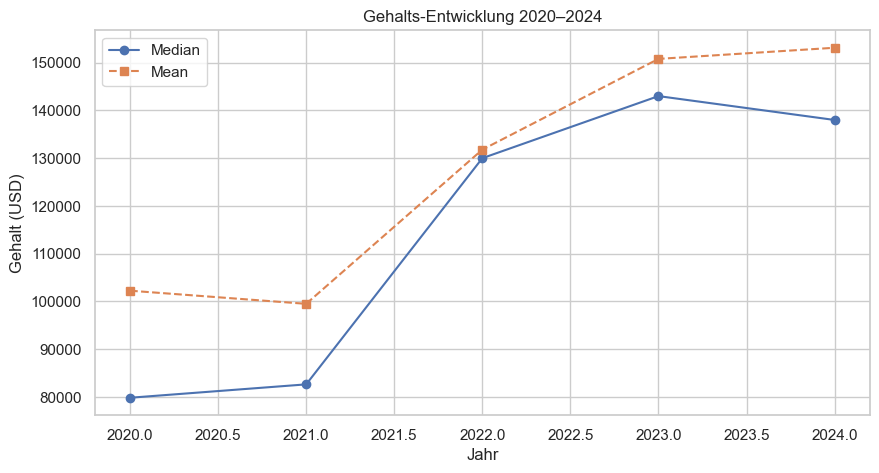

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(salary_by_year["work_year"], salary_by_year["median"], marker="o", label = "Median")
ax.plot(salary_by_year["work_year"], salary_by_year["mean"], marker="s", linestyle="--", label = "Mean")

ax.set_title("Gehalts-Entwicklung 2020–2024")
ax.set_xlabel("Jahr")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.show()

/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_22552/4152947895.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


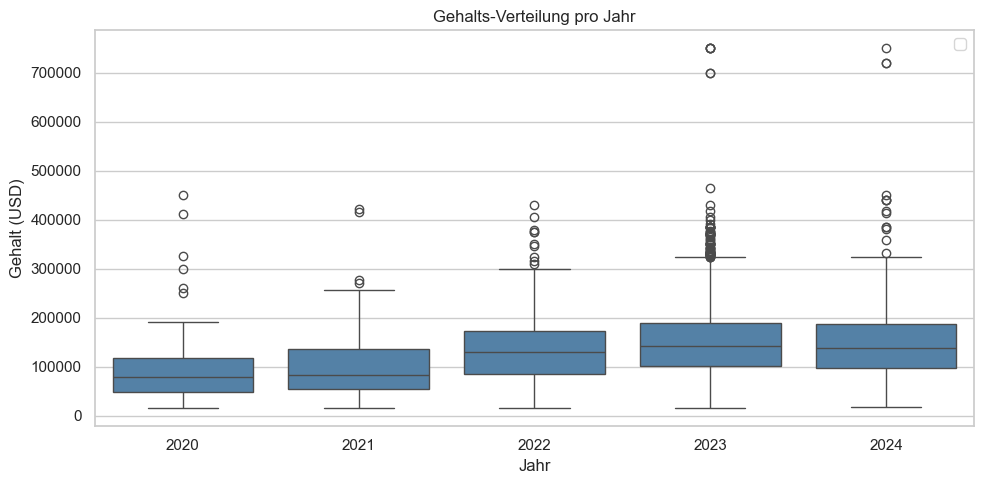

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=ds_salaries, x="work_year", y="salary_in_usd", ax=ax, color="steelblue")

ax.set_title("Gehalts-Verteilung pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.tight_layout()

plt.show()



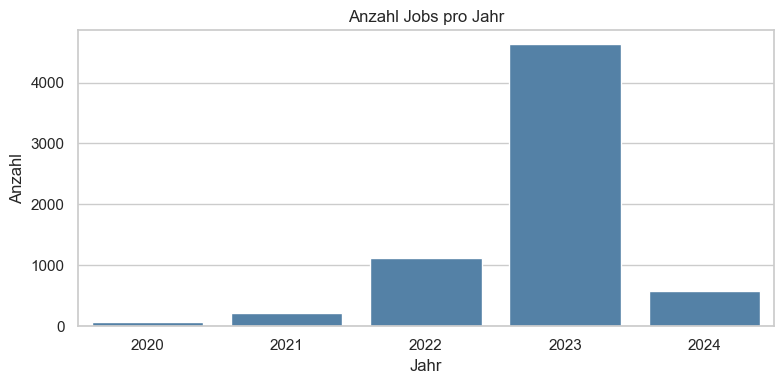

In [45]:
fig, ax = plt.subplots(figsize=(8,4))

sns.barplot(data=salary_by_year,x = "work_year", y = "count", ax=ax, color="steelblue")

ax.set_title("Anzahl Jobs pro Jahr")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl")
plt.tight_layout()
plt.show()

## 4. Einfluss des Erfahrungslevels (Junior → Senior → Executive)

In [50]:
salary_by_experience = (
    ds_salaries.groupby("experience_level")["salary_in_usd"]
        .agg(mean = "mean", median = "median", count = "count")
        .round({"mean" : 2, "median" : 2})
        .reset_index()
                        )
salary_by_experience

,experience_level,mean,median,count
0,Entry-level,84448.92,75000.0,565
1,Executive-level,189687.35,184560.0,254
2,Mid-level,119019.81,106500.0,1675
3,Senior-level,162071.06,153600.0,4105


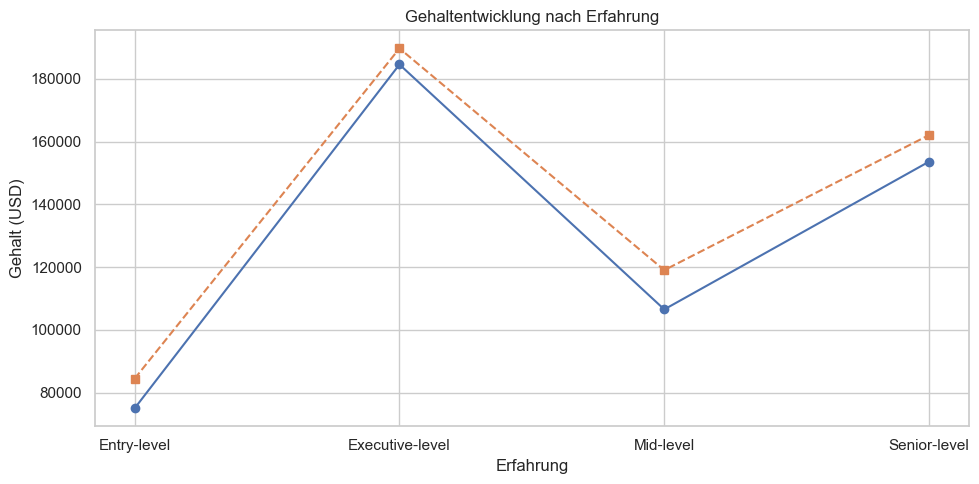

In [57]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(salary_by_experience["experience_level"],salary_by_experience["median"], label = "median",marker="o")
ax.plot(salary_by_experience["experience_level"],salary_by_experience["mean"], label = "mean", linestyle="--"  ,marker="s")

ax.set_title("Gehaltentwicklung nach Erfahrung")
ax.set_xlabel("Erfahrung")
ax.set_ylabel("Gehalt (USD)")

plt.tight_layout()
plt.show()

/var/folders/_d/4llk731n547f811mb_kz1m2h0000gn/T/ipykernel_22552/1735725309.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


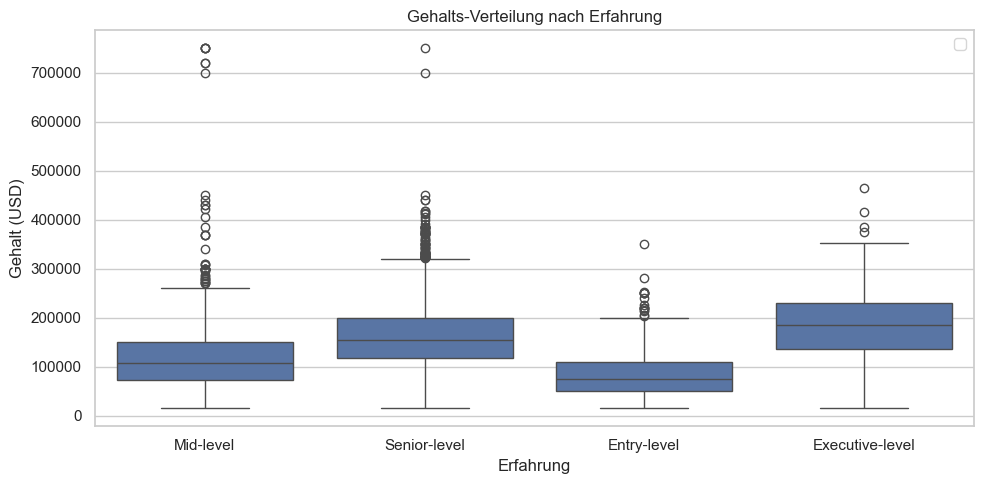

In [61]:
fig, ax = plt.subplots(figsize = (10,5))

sns.boxplot(data=ds_salaries, x="experience_level",y="salary_in_usd")

ax.set_title("Gehalts-Verteilung nach Erfahrung")
ax.set_xlabel("Erfahrung")
ax.set_ylabel("Gehalt (USD)")

ax.legend()

plt.tight_layout()

plt.show()

## 5. Top & Bottom Job-Titel nach Gehalt

## 6. Remote-Arbeit: zahlt sich das aus?

## 7. Geografische Unterschiede: USA vs. Europa vs. Rest

In [68]:
salary_by_geo = (ds_salaries.groupby("employee_residence")["salary_in_usd"]
                 .agg(mean = "mean", median = "median", count = "count")
                 .round({"mean" : 2, "median" : 2})
                 .reset_index())
print(salary_by_geo)

salary_by_curr = (ds_salaries.groupby("salary_currency")["salary_in_usd"]
                 .agg(mean = "mean", median = "median", count = "count")
                 .round({"mean" : 2, "median" : 2})
                 .reset_index())
salary_by_curr

      employee_residence       mean    median  count
0                Algeria  100000.00  100000.0      1
1         American Samoa   45555.00   45555.0      1
2                Andorra   50745.00   50745.0      1
3              Argentina   56444.44   60000.0      9
4                Armenia   33500.00   33500.0      2
..                   ...        ...       ...    ...
82  United Arab Emirates  100000.00  115000.0      3
83        United Kingdom  103392.37   91118.0    401
84         United States  157780.94  149000.0   5305
85            Uzbekistan   82000.00  100000.0      3
86               Vietnam   58480.00   50000.0      5

[87 rows x 4 columns]


,salary_currency,mean,median,count
0,AUD,78538.18,81838.0,11
1,BRL,26168.75,23739.0,4
2,CAD,99896.36,87738.0,39
3,CHF,101659.40,104697.0,5
4,CLP,40038.00,40038.0,1
5,DKK,31192.67,28609.0,3
6,EUR,67190.08,62211.0,292
7,GBP,88487.48,74221.0,334
8,HKD,65058.00,65058.0,1
9,HUF,29892.67,35735.0,3


## 8. Unternehmensgröße als Faktor

## 9. Fazit & Key Findings

*(wird nach Abschluss der Analyse ausgefüllt)*